# AdaBoost — Poker Hand Prediction
Dự đoán sức mạnh bài Poker sử dụng thuật toán AdaBoost trên UCI Poker Hand Dataset.

## 1. Import thư viện

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Tải dữ liệu

In [22]:
train_path = r'../data/train.csv'
test_path  = r'../data/test.csv'

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

print('Train shape:', df_train.shape)
print('Test shape :', df_test.shape)
print()
print('5 dòng đầu tập train:')
display(df_train.head())

Train shape: (25010, 11)
Test shape : (1000000, 11)

5 dòng đầu tập train:


,S1,C1,S2,C2,S3,C3,S4,C4,S5,C5,Class
0,1,10,1,11,1,13,1,12,1,1,9
1,2,11,2,13,2,10,2,12,2,1,9
2,3,12,3,11,3,13,3,10,3,1,9
3,4,10,4,11,4,1,4,13,4,12,9
4,4,1,4,13,4,12,4,11,4,10,9


## 3. Chuẩn bị dữ liệu

In [23]:
X_train = df_train.drop('Class', axis=1)
y_train = df_train['Class']

X_test = df_test.drop('Class', axis=1)
y_test = df_test['Class']

# Phân phối class trong tập train
print('Phân phối class trong tập train:')
print(y_train.value_counts().sort_index())

Phân phối class trong tập train:
Class
0    12493
1    10599
2     1206
3      513
4       93
5       54
6       36
7        6
8        5
9        5
Name: count, dtype: int64


## 4. Xây dựng Pipeline

In [24]:
# Pipeline: Chuẩn hóa dữ liệu 
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', AdaBoostClassifier(
        estimator   = DecisionTreeClassifier(max_depth=1),  # weak learner: decision stump
        n_estimators= 50,    # số weak learners
        learning_rate= 1.0,
        random_state= 42
    ))
])

print('Pipeline created:')
print(pipeline)

Pipeline created:
Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                    random_state=42))])


## 5. Cross-Validation (3 folds)
Đánh giá mô hình bằng StratifiedKFold 

In [25]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print('Đang chạy Cross-Validation (3 folds)...')
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

print(f'CV Scores  : {cv_scores}')
print(f'CV Mean    : {cv_scores.mean():.4f}')
print(f'CV Std     : {cv_scores.std():.4f}')

Đang chạy Cross-Validation (3 folds)...


CV Scores  : [0.48494662 0.44872256 0.48380518]
CV Mean    : 0.4725
CV Std     : 0.0168


## 6. Huấn luyện và đánh giá trên tập Test

In [26]:
print('Đang huấn luyện mô hình...')
pipeline.fit(X_train, y_train)
print('Hoàn thành!')

y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'\nAccuracy trên tập test: {acc:.4f} ({acc*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

Đang huấn luyện mô hình...
Hoàn thành!

Accuracy trên tập test: 0.4925 (49.25%)

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.85      0.63    501209
           1       0.43      0.15      0.22    422498
           2       0.00      0.00      0.00     47622
           3       0.00      0.00      0.00     21121
           4       0.00      0.00      0.00      3885
           5       0.00      0.00      0.00      1996
           6       0.00      0.00      0.00      1424
           7       0.00      0.00      0.00       230
           8       0.00      0.00      0.00        12
           9       0.00      0.00      0.00         3

    accuracy                           0.49   1000000
   macro avg       0.09      0.10      0.09   1000000
weighted avg       0.43      0.49      0.41   1000000



## 7. Confusion Matrix

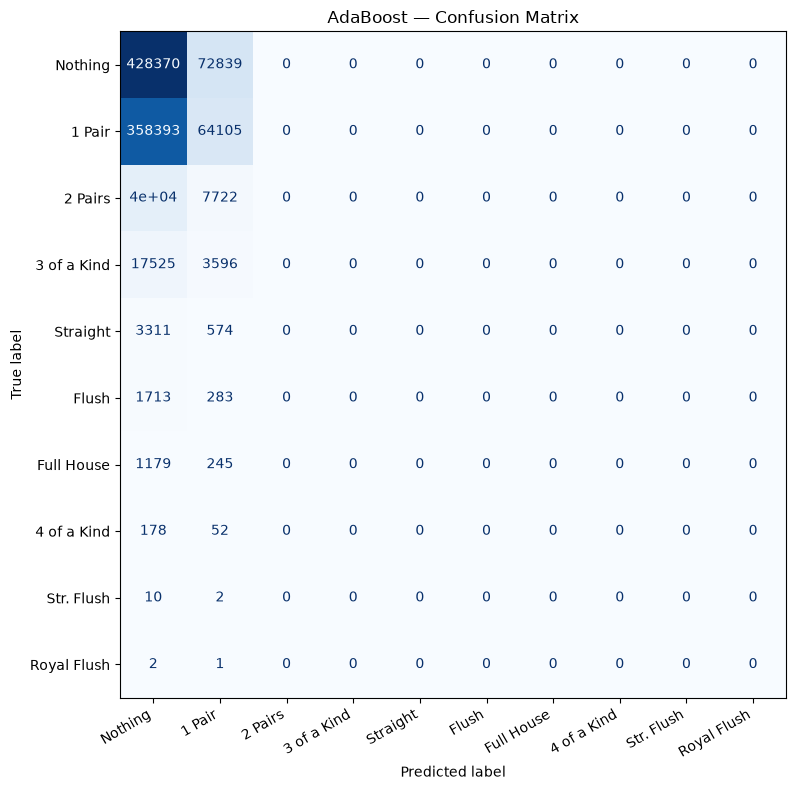

In [27]:
class_names = ['Nothing','1 Pair','2 Pairs','3 of a Kind',
               'Straight','Flush','Full House','4 of a Kind',
               'Str. Flush','Royal Flush']

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('AdaBoost — Confusion Matrix')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 8. Accuracy theo số estimators

n_estimators= 10 -> Accuracy: 0.4824
n_estimators= 20 -> Accuracy: 0.4715
n_estimators= 30 -> Accuracy: 0.4500
n_estimators= 40 -> Accuracy: 0.4931
n_estimators= 50 -> Accuracy: 0.4925
n_estimators= 60 -> Accuracy: 0.4754
n_estimators= 70 -> Accuracy: 0.4725
n_estimators= 80 -> Accuracy: 0.4721
n_estimators= 90 -> Accuracy: 0.4660
n_estimators=100 -> Accuracy: 0.4708


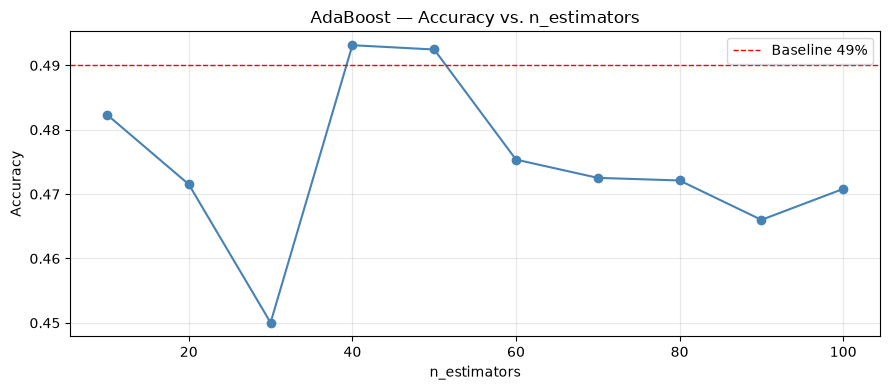

In [28]:
# Thử nghiệm với n_estimators từ 10 đến 100
estimator_range = range(10, 101, 10)
scores = []

for n in estimator_range:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=n,
            random_state=42
        ))
    ])
    pipe.fit(X_train, y_train)
    scores.append(accuracy_score(y_test, pipe.predict(X_test)))
    print(f'n_estimators={n:3d} -> Accuracy: {scores[-1]:.4f}')

plt.figure(figsize=(9, 4))
plt.plot(list(estimator_range), scores, marker='o', color='steelblue', linewidth=1.5)
plt.axhline(0.49, color='red', linestyle='--', linewidth=1, label='Baseline 49%')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('AdaBoost — Accuracy vs. n_estimators')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Nhận xét kết quả

- **Accuracy ~49%** — đúng với kết quả trong báo cáo gốc (Table 2).
- AdaBoost chỉ học được **Class 0** (Nothing) và **Class 1** (1 Pair) vì 2 class này chiếm ~92% dữ liệu.
- **Class 2–9** đều có precision và recall = 0.00 do dữ liệu mất cân bằng nghiêm trọng.
- Decision Stump (max_depth=1) quá đơn giản để học được quan hệ phi tuyến của Poker Hand.
- Đây là lý do nhóm chọn **Neural Network (MLP)** thay thế — đạt **96% accuracy**.